In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch 
import torch.nn as nn
from torchvision import datasets,transforms
from torchvision.models import efficientnet_b3,EfficientNet_B3_Weights
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torch.utils.data import DataLoader,random_split
import numpy as np
from PIL import ImageOps

In [ ]:

train_transforms = transforms.Compose([ transforms.Resize((300,300))
                                        ,transforms.ToTensor()
                                      ,transforms.Normalize(
                                            (0.485, 0.456, 0.406),
                                            (0.229, 0.224, 0.225)
                                      )])

CLASSIFICATION_DIR = os.environ.get("CLASSIFICATION_DIR","./data/dataset") #Point this to the classification dataset
fulltraindataset = datasets.ImageFolder(root=os.path.join(CLASSIFICATION_DIR,'train'),transform=train_transforms)
train_dataset,dev_dataset = random_split(fulltraindataset,[4500,500])
test_dataset = datasets.ImageFolder(root=os.path.join(CLASSIFICATION_DIR,'test'),transform=train_transforms)

In [5]:
train_dataloader = DataLoader(train_dataset,64,shuffle=True)
dev_dataloader = DataLoader(dev_dataset,64,shuffle=True)
test_dataloader = DataLoader(test_dataset,2,shuffle=True)
class_labels = ['glioma','meningioma','normal','pituitary']

In [ ]:
weights = EfficientNet_B3_Weights.DEFAULT
model = efficientnet_b3(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features,4)
for params in model.parameters():
    params.requires_grad = False
for params in model.features[-2].parameters():
    params.requires_grad = True    
for params in model.features[-1].parameters():
    params.requires_grad = True
for params in model.classifier[1].parameters():
    params.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(
    '...........' #for checkpointing
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=0.0001,weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()
target_layers = [model.features[-1][0]]
cam = GradCAM(model,target_layers)


In [7]:
def evaluate(model,dataloader,dataset):
    model.eval()
    with torch.no_grad():
            correct = 0
            for (batch_x,batch_y) in (dataloader):
                batch_x = batch_x.to('cuda')
                batch_y = batch_y.to('cuda')
                y_pred = model(batch_x)
                correct+=y_pred.argmax(dim=1).eq(batch_y).sum().item()
            return (correct/len(dataset))*100


In [8]:
def trainingloop(model,optimizer,loss_fn):
    model.train()
    correct = 0
    total_loss=0
    for (batch_x,batch_y) in (train_dataloader):
        batch_x = batch_x.to(torch.device('cuda'))
        batch_y = batch_y.to(torch.device('cuda'))
        y_pred = model(batch_x)
        loss = loss_fn(y_pred,batch_y)
        total_loss+=loss.item()
        correct+=y_pred.argmax(dim=1).eq(batch_y).sum().item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Loss : {total_loss/len(train_dataloader)}")
    return (correct/len(train_dataset))*100

In [ ]:

best_dev_acc=checkpoint['best_dev_acc']
for i in range(10):
    train_acc = trainingloop(model,optimizer,loss_fn)
    dev_acc = evaluate(model,dev_dataloader,dev_dataset)
    print(f"Epoch : {i+1} \nTrain Accuracy : {train_acc}\nDev Accuracy : {dev_acc}")
  
    if dev_acc>best_dev_acc:
         best_dev_acc=dev_acc
         torch.save({
             "model_state_dict":model.state_dict(),
             "best_dev_acc":best_dev_acc
         },'...........' ) #-> Specify Output location here 
         print("Best Model Saved Succesfully!")

Loss : 0.18786131580111007
Epoch : 1 
Train Accuracy : 93.44444444444444
Dev Accuracy : 93.60000000000001
Best Model Saved Succesfully!
Loss : 0.14110214200238108
Epoch : 2 
Train Accuracy : 95.02222222222223
Dev Accuracy : 94.8
Best Model Saved Succesfully!
Loss : 0.10632907955999106
Epoch : 3 
Train Accuracy : 96.53333333333333
Dev Accuracy : 95.6
Best Model Saved Succesfully!
Loss : 0.08625570915534463
Epoch : 4 
Train Accuracy : 97.31111111111112
Dev Accuracy : 96.6
Best Model Saved Succesfully!
Loss : 0.07019047077063104
Epoch : 5 
Train Accuracy : 97.91111111111111
Dev Accuracy : 96.39999999999999


In [30]:
def ConfusionMatrix(model,dataloader,dataset):
    model.eval()
    all_preds=[]
    all_labels=[]
    correct = 0
    std = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device='cuda')
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device='cuda')
    for idx,(batch_x,batch_y) in enumerate(dataloader):
        batch_x.requires_grad_()
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        y_pred = model(batch_x)
        pred = y_pred.argmax(dim=1)
        for i in range(2):
            all_preds.append(pred[i].item())
            all_labels.append(batch_y[i].item())
        if idx%100==0:
            target = [ClassifierOutputTarget(int(pred)) for pred in y_pred.argmax(dim=1)]
            gray_cam = cam(batch_x,target)
            images = batch_x*std+mean
            fig,axes = plt.subplots(1,2)
            for i in range(2):
                original = images[i].permute(1,2,0).detach().cpu().numpy()
                original = np.clip(original,0,1)
                visualization = show_cam_on_image(
                    original,
                    gray_cam[i],
                    use_rgb = True
                )
                axes[i].imshow(visualization)
                axes[i].set_title(
                    f"Pred: {class_labels[y_pred[i].argmax().item()]} | "
                    f"Actual: {class_labels[batch_y[i].item()]}"
                                )
                axes[i].axis("off")
            plt.tight_layout()
            plt.show()
            plt.close(fig)
        correct+=y_pred.argmax(dim=1).eq(batch_y).sum().item()
    return ((correct/len(dataset))*100,all_preds,all_labels)
        

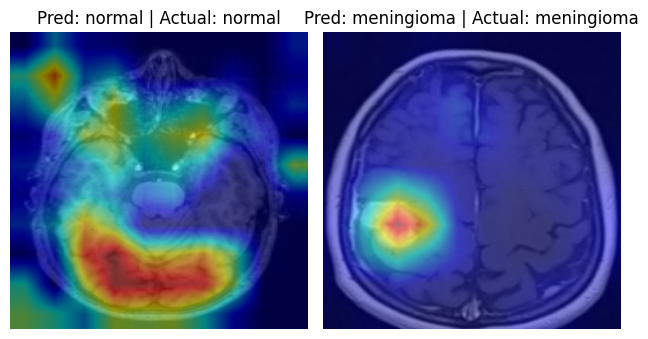

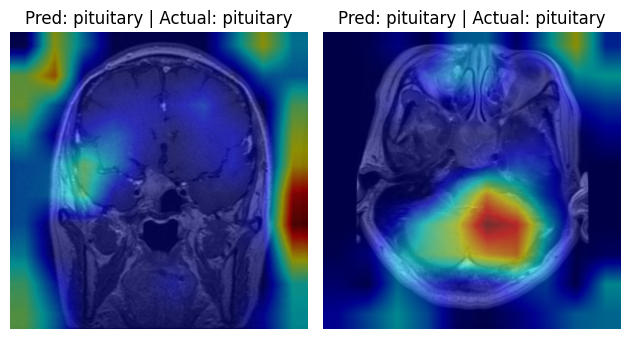

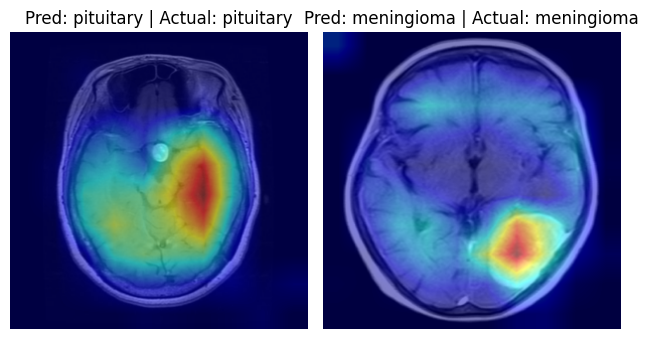

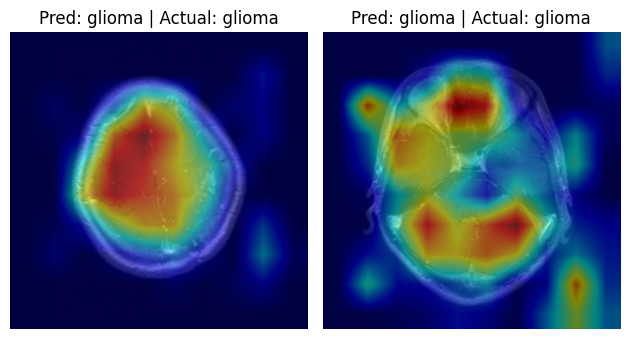

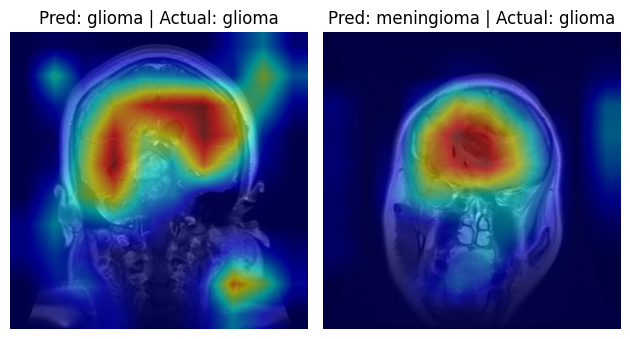

[[221  30   0   3]
 [  5 286   5  10]
 [  0   0 140   0]
 [  0   3   0 297]]
              precision    recall  f1-score   support

      glioma       0.98      0.87      0.92       254
  meningioma       0.90      0.93      0.92       306
      normal       0.97      1.00      0.98       140
   pituitary       0.96      0.99      0.97       300

    accuracy                           0.94      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.94      0.94      1000

Test Accuracy : 94.39999999999999


In [31]:
from sklearn.metrics import confusion_matrix,classification_report


test_acc,preds,labels= ConfusionMatrix(model,test_dataloader,test_dataset)
cm = confusion_matrix(labels,preds)
print(cm)
print(classification_report(labels,preds,target_names=class_labels))
print(f"Test Accuracy : {test_acc}")